# Fitting and plotting of Gompertz curve.

# VIVA Q&A

**Q1: What is the main goal of this code?**
**Answer:** It fits a Gompertz curve to a microbial dataset to model how bacteria grow over time until they reach a maximum limit.

**Q2: What is the Gompertz equation used in your code?**
**Answer:** The equation is `y = a * exp(-b * exp(-c * t))`. It creates an "S-shaped" curve that grows fast but eventually hits a flat ceiling.

**Q3: Why did you use `y_data.max()` as the initial guess for parameter 'a'?**
**Answer:** In the Gompertz formula, 'a' represents the maximum ceiling (or asymptote) of the curve. The highest value in our raw data is the most logical starting guess for that ceiling.

**Q4: Why do we use `curve_fit` from SciPy?**
**Answer:** Because the Gompertz formula is non-linear. `curve_fit` is an optimization engine that tests thousands of numbers to find the most accurate values for 'a', 'b', and 'c'.

**Q5: Why didn't you convert calendar dates to numbers in this code, like you did in Practical 1?**
**Answer:** The `t [h]` column in the microbial dataset is already given as numerical hours (0, 1, 2, 3...). It is already in a format that the math engine can understand, so no conversion is needed.

**Q6: What is the purpose of the Covariance Matrix Heatmap?**
**Answer:** It shows how confident the model is in its calculated parameters. Low variance in the matrix means our parameter estimates (a, b, c) are highly accurate and reliable.

**Q7: What does the R-squared ($R^2$) score prove?**
**Answer:** It measures accuracy. An $R^2$ score close to 1.0 (or 100%) proves mathematically that our generated Gompertz curve is a near-perfect fit for the real microbial data.

--- Practical 2: Gompertz Curve Fitting ---
Loading dataset...

Calculating Initial Guesses for Parameters (a, b, c)...
Initial Guesses -> a: 0.71, b: 1.00, c: 0.0010

Fitting the Gompertz curve to the data...
Optimized values for best fit: a = 1.0816, b = 2.9094, c = 2.3556e-02

Covariance matrix of the parameters (a, b, c):
[[ 7.53574559e-04 -7.22103742e-05 -1.79070293e-05]
 [-7.22103742e-05  6.19619264e-04  5.48047024e-06]
 [-1.79070293e-05  5.48047024e-06  4.53519501e-07]]


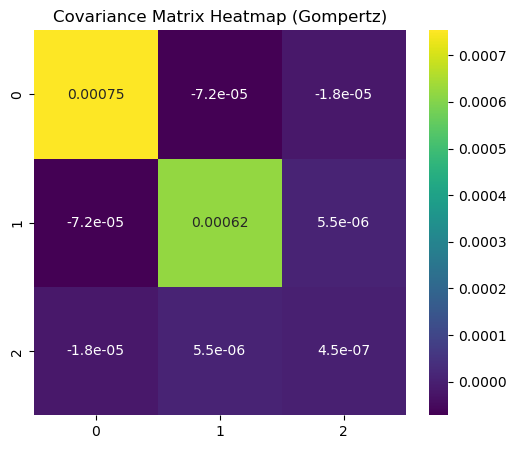


Coefficient of Determination (R^2 Score) = 0.9828


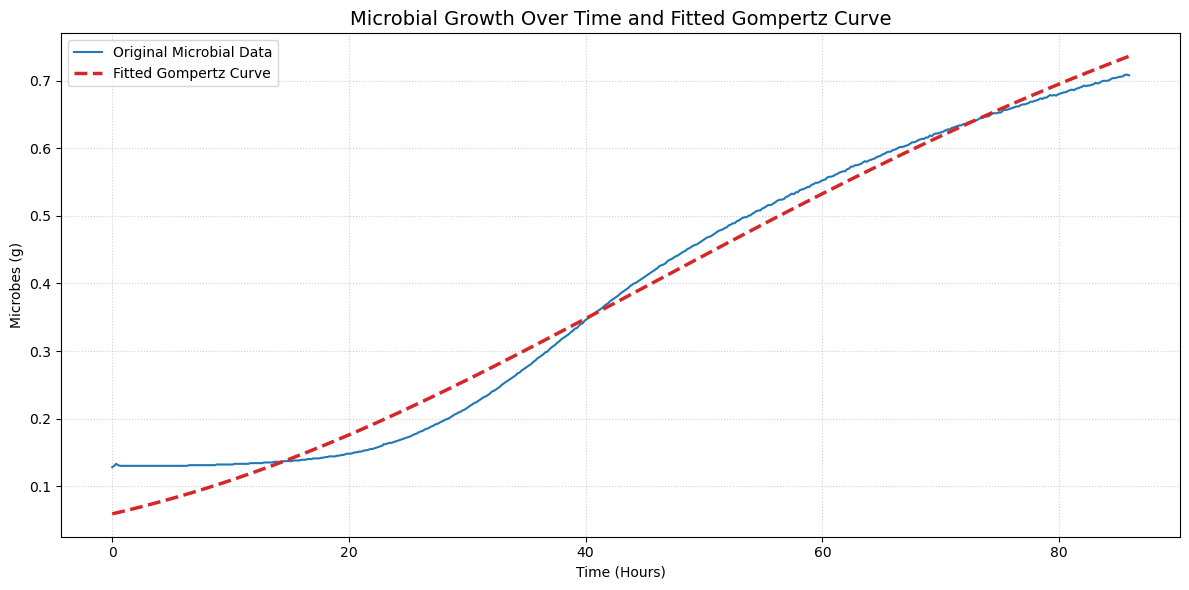

In [20]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def fit_gompertz_curve():
    print("--- Practical 2: Gompertz Curve Fitting ---")
    
    # 0. Load Dataset using the new file path
    path = r"C:\Users\Mahesh Khairnar\Time Series Analysis and Forecasting\Practical Datasets\microbial_growth_curve.csv"
    print("Loading dataset...")
    df = pd.read_csv(path)

    # 1. Data Preparation 
    # Sort values just in case they are out of order
    df.sort_values('t [h]', inplace=True)
    
    # The 't [h]' column is already numerical (hours), so NO date conversion is needed!
    x_numerical = df['t [h]']
    y_data = df['microbes(g)']

    # 2. Define the Gompertz Model
    def gompertz_func(t, a, b, c):
        return a * np.exp(-b * np.exp(-c * t))

    print("\nCalculating Initial Guesses for Parameters (a, b, c)...")
    
    # 'a' is the ceiling (asymptote), so we guess the maximum Y value
    a_guess = y_data.max()
    b_guess = 1.0
    c_guess = 0.001 
    
    print(f"Initial Guesses -> a: {a_guess:.2f}, b: {b_guess:.2f}, c: {c_guess:.4f}")

    print("\nFitting the Gompertz curve to the data...")
    p0 = (a_guess, b_guess, c_guess)
    
    # Run the non-linear optimization
    popt, pcov = curve_fit(gompertz_func, x_numerical, y_data, p0=p0, maxfev=10000)
    
    print(f"Optimized values for best fit: a = {popt[0]:.4f}, b = {popt[1]:.4f}, c = {popt[2]:.4e}")
    print("\nCovariance matrix of the parameters (a, b, c):")
    print(pcov)

    # 3. Plot the Covariance Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(pcov, cmap='viridis', annot=True)
    plt.title("Covariance Matrix Heatmap (Gompertz)")
    plt.show()

    # 4. Generate the trend line and R-Squared Score
    y_pred = gompertz_func(x_numerical, *popt)
    r_squared = r2_score(y_data, y_pred)
    print(f"\nCoefficient of Determination (R^2 Score) = {r_squared:.4f}")

    # 5. Plot the Original Data vs Gompertz Curve
    plt.figure(figsize=(12, 6))
    
    # Raw Data
    plt.plot(x_numerical, y_data, label='Original Microbial Data', color='tab:blue')
    # Fitted Gompertz Curve
    plt.plot(x_numerical, y_pred, '--', label='Fitted Gompertz Curve', color='tab:red', linewidth=2.5)
    
    plt.title('Microbial Growth Over Time and Fitted Gompertz Curve', fontsize=14)
    plt.xlabel('Time (Hours)')
    plt.ylabel('Microbes (g)')
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    fit_gompertz_curve()